# Convolutional Neural Network (CNN)

## 1. CNN là gì và vì sao cần nó?

CNN là một loại mạng nơ-ron giúp máy tính "nhìn" và hiểu ảnh, theo cách na ná cách con người nhận diện vật thể trong đời thực. Thay vì xem toàn bộ ảnh một lúc như mạng feedforward (ANN), CNN chia ảnh ra từng vùng nhỏ, tìm các đặc trưng cục bộ như đường thẳng, góc, vòng tròn, rồi ghép lại để đưa ra dự đoán.

### Một câu hỏi kinh điển: vì sao không dùng ANN cho ảnh?

Một ảnh 28×28 grayscale có 784 pixel. Nếu cho vào MLP (như bài MNIST trước), tầng đầu cần $784 \times 128 = 100.352$ tham số. Với ảnh màu 224×224×3, con số là $\sim 19$ triệu chỉ riêng tầng đầu. Hơn nữa, MLP coi mỗi pixel là một đặc trưng độc lập — nó *quên mất* rằng pixel cạnh nhau có quan hệ với nhau (cùng tạo nên một cái mắt, một cái mũi).

CNN giải quyết hai vấn đề này bằng:
1. **Chia sẻ trọng số** (weight sharing): cùng một filter dùng cho cả ảnh → ít tham số đi rất nhiều.
2. **Kết nối cục bộ** (local connectivity): mỗi neuron chỉ nhìn một vùng nhỏ → giữ được tính chất không gian của ảnh.

### Trực giác bằng ví dụ
Khi nhìn một con mèo, ta không xem hết cả ảnh ngay lập tức. Ta nhận ra tai mèo (hình tam giác), mắt mèo (hình tròn), ria mèo (đường thẳng), rồi não bộ mới kết luận "đây là mèo". CNN cũng làm vậy: dùng các "kính lúp" nhỏ (filter) quét qua ảnh, tìm từng đặc trưng nhỏ, càng lên các tầng sâu càng học được đặc trưng phức tạp.

## 2. Các thành phần chính của CNN

### 2.1. Tầng tích chập (Convolution Layer)

Đây là "đôi mắt" của CNN. Nó dùng một bộ lọc (filter / kernel) trượt qua ảnh, tại mỗi vị trí tính tích chập rồi sinh ra một con số trong feature map.

#### Công thức tích chập

$$
S(i, j) = \sum_{m=0}^{F-1} \sum_{n=0}^{F-1} I(i+m,\ j+n) \cdot K(m, n)
$$

Trong đó:
- $I$: ảnh đầu vào.
- $K$: filter kích thước $F \times F$.
- $S(i, j)$: giá trị tại vị trí $(i, j)$ trong feature map.

Đọc bằng lời: lấy vùng $F \times F$ của ảnh tại vị trí $(i, j)$, nhân từng phần tử với phần tử tương ứng của filter, rồi cộng tất cả lại.

*Lưu ý kỹ thuật:* trong toán học, tích chập "thật" có một bước lật filter; tích chập trong deep learning thực ra là **cross-correlation** (không lật). Nhưng vì filter được học từ dữ liệu nên việc lật hay không không quan trọng — kết quả huấn luyện như nhau.

### 2.2. Minh hoạ đầy đủ với số "7"

Hãy khám phá tầng tích chập qua một ví dụ cụ thể. Ta dùng filter phát hiện đường ngang để tìm nét trên cùng của số "7".

**Ảnh đầu vào (6×6):**
$$ I = \begin{bmatrix} 1 & 1 & 1 & 1 & 1 & 1 \\ 0 & 0 & 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 & 0 & 0 \\ 0 & 0 & 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 & 0 & 0 \\ 1 & 0 & 0 & 0 & 0 & 0 \end{bmatrix} $$

Hàng trên cùng toàn 1 = nét ngang, các hàng dưới có một số 1 chéo từ phải sang trái = thân số 7.

**Filter phát hiện đường ngang (3×3):**
$$ K = \begin{bmatrix} 1 & 1 & 1 \\ 0 & 0 & 0 \\ -1 & -1 & -1 \end{bmatrix} $$

Filter này phản hồi mạnh khi vùng dưới của patch tối, vùng trên sáng — đặc trưng của một đường ngang nét đậm trên nền trắng phía dưới.

**Kích thước feature map:** với stride 1, không padding:
$$\text{output} = \Big\lfloor\frac{6-3}{1}\Big\rfloor + 1 = 4$$
→ feature map 4×4.

#### Tính từng vị trí

Đối với mỗi vị trí $(i, j)$ của output, ta lấy patch $I[i:i+3,\ j:j+3]$, nhân từng phần tử với $K$, rồi cộng dồn.

**$(0, 0)$:** patch = $\begin{bmatrix}1&1&1\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1+1+1 = 3$

**$(0, 1)$:** patch = $\begin{bmatrix}1&1&1\\0&0&0\\0&0&1\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(0, 2)$:** patch = $\begin{bmatrix}1&1&1\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(0, 3)$:** patch = $\begin{bmatrix}1&1&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 3 + 0 + (-1) = 2$

**$(1, 0)$:** patch = $\begin{bmatrix}0&0&0\\0&0&0\\0&0&1\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$

**$(1, 1)$:** patch = $\begin{bmatrix}0&0&0\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$  *(không phải +1, đây là chỗ cần chú ý kẻo nhầm dấu)*

**$(1, 2)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(1, 3)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(2, 0)$:** patch = $\begin{bmatrix}0&0&0\\0&0&1\\0&1&0\end{bmatrix}$ → tổng $= 0 + 0 + (-1) = -1$

**$(2, 1)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(2, 2)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(2, 3)$:** patch = $\begin{bmatrix}1&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 0)$:** patch = $\begin{bmatrix}0&0&1\\0&1&0\\1&0&0\end{bmatrix}$ → tổng $= 1 + 0 + (-1) = 0$

**$(3, 1)$:** patch = $\begin{bmatrix}0&1&0\\1&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 2)$:** patch = $\begin{bmatrix}1&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 1 + 0 + 0 = 1$

**$(3, 3)$:** patch = $\begin{bmatrix}0&0&0\\0&0&0\\0&0&0\end{bmatrix}$ → tổng $= 0$

**Feature map hoàn chỉnh:**
$$ S = \begin{bmatrix} 3 & 2 & 2 & 2 \\ -1 & -1 & 0 & 1 \\ -1 & 0 & 1 & 1 \\ 0 & 1 & 1 & 0 \end{bmatrix} $$

Nhìn vào feature map: dòng đầu có giá trị lớn (2-3) — filter "kêu to" nhất ở vùng có nét ngang trên cùng. Đó chính là điều ta muốn: filter đã phát hiện đúng vị trí đường ngang của số 7.

![Hình minh hoạ phép tích chập trên ảnh số 7](attachment:conv7.png)


#### Padding và Stride

- **Padding ($P$)**: thêm số 0 quanh ảnh. Nếu $P=0$ (như trên), feature map nhỏ hơn ảnh gốc. Padding `'same'` thêm vừa đủ để output cùng kích thước input.
- **Stride ($S$)**: bước trượt của filter. $S=1$ trượt từng pixel, $S=2$ nhảy cách 2 pixel — output nhỏ đi một nửa.

Công thức kích thước đầu ra (với phép chia làm tròn xuống):
$$
\text{Output Height} = \Big\lfloor\frac{H - F + 2P}{S}\Big\rfloor + 1
$$
$$
\text{Output Width} = \Big\lfloor\frac{W - F + 2P}{S}\Big\rfloor + 1
$$

Kiểm tra với ví dụ: $H = W = 6$, $F=3$, $P=0$, $S=1$ → $(6-3)/1 + 1 = 4$, đúng với feature map 4×4.

### 2.3. Hàm kích hoạt ReLU

Sau khi có feature map, ta áp dụng ReLU để loại bỏ các giá trị âm. Ý tưởng: giá trị âm thường nghĩa là vùng đó *không* có đặc trưng filter đang tìm — bỏ đi cho đỡ ồn.

$$ \text{ReLU}(x) = \max(0, x) $$

Áp dụng vào feature map ở trên:

$$ \text{ReLU}(S) = \begin{bmatrix} 3 & 2 & 2 & 2 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 1 \\ 0 & 1 & 1 & 0 \end{bmatrix} $$

Các -1 đã bị nén về 0. Vì sao chọn ReLU thay vì sigmoid hay tanh? Vì sigmoid và tanh có gradient bão hoà ở vùng giá trị lớn — gradient gần 0 → mạng học rất chậm khi đi sâu. ReLU tránh được vấn đề này (gradient là 1 với x > 0).

### 2.4. Tầng Pooling

Pooling "tóm tắt" feature map, giảm kích thước nhưng giữ thông tin chính. Loại phổ biến nhất: **Max Pooling** — trong mỗi vùng nhỏ chỉ giữ giá trị lớn nhất.

Áp dụng max pooling 2×2 stride 2 lên feature map sau ReLU:

- Vùng góc trên trái $\{3, 2, 0, 0\}$ → max = 3
- Vùng góc trên phải $\{2, 2, 0, 1\}$ → max = 2
- Vùng góc dưới trái $\{0, 0, 0, 1\}$ → max = 1
- Vùng góc dưới phải $\{1, 1, 1, 0\}$ → max = 1

$$ P = \begin{bmatrix} 3 & 2 \\ 1 & 1 \end{bmatrix} $$

Ngoài giảm kích thước (giúp tính nhanh hơn), pooling còn cho mạng tính **bất biến với dịch chuyển nhỏ**: nếu ảnh dịch sang phải vài pixel, max pooling vẫn ra cùng một giá trị.

![Trước và sau khi áp dụng ReLU](attachment:relu.png)


![Trước và sau khi áp dụng MaxPooling](attachment:pool.png)


### 2.5. Tầng Fully Connected

Sau vài tầng conv + pool, ta "duỗi" feature map cuối thành vector và đưa qua một tầng Linear thông thường — đây là bước "ghép các đặc trưng lại để ra quyết định".

$$ y = Wx + b $$

**Ví dụ:** lấy feature map sau pooling = $\begin{bmatrix}3 & 2 \\ 1 & 1\end{bmatrix}$, duỗi thành $x = [3, 2, 1, 1]$.

Phân loại 2 lớp: "là 7" / "không phải 7". Cho:
$$ W = \begin{bmatrix} 0.5 & 0.2 & 0.3 & 0.4 \\ -0.1 & 0.3 & 0.2 & -0.5 \end{bmatrix},\quad b = \begin{bmatrix}0.1\\0.2\end{bmatrix} $$

Tính từng output:
- $y_0 = (0.5 \cdot 3 + 0.2 \cdot 2 + 0.3 \cdot 1 + 0.4 \cdot 1) + 0.1 = (1.5 + 0.4 + 0.3 + 0.4) + 0.1 = 2.6 + 0.1 = 2.7$
- $y_1 = (-0.1 \cdot 3 + 0.3 \cdot 2 + 0.2 \cdot 1 + (-0.5) \cdot 1) + 0.2 = (-0.3 + 0.6 + 0.2 - 0.5) + 0.2 = 0.0 + 0.2 = 0.2$

Sau softmax:
$$P(\text{là 7}) = \frac{e^{2.7}}{e^{2.7} + e^{0.2}} \approx 0.924$$
$$P(\text{không phải 7}) = \frac{e^{0.2}}{e^{2.7} + e^{0.2}} \approx 0.076$$

Mạng kết luận: 92.4% xác suất là số 7.

## 3. Tóm tắt pipeline CNN

1. **Conv** → tìm đặc trưng cục bộ → feature map.
2. **ReLU** → giữ tín hiệu dương, bỏ tín hiệu âm.
3. **Pool** → tóm tắt + giảm kích thước.
4. (Lặp lại 1-3 nhiều lần để học đặc trưng từ thấp đến cao.)
5. **Flatten + FC** → ra quyết định cuối cùng.
6. **Softmax + CrossEntropy** (lúc train) → tính loss.

Càng đi sâu vào mạng, các filter càng học được đặc trưng phức tạp hơn: tầng đầu phát hiện cạnh, tầng giữa phát hiện hình tròn / góc, tầng cuối phát hiện cả "con mèo" hay "chữ số 7".

![Tầng Fully Connected](attachment:fc.png)


![Pipeline CNN tổng hợp](attachment:pipe.png)


# BÀI THỰC HÀNH: PHÂN LOẠI MNIST BẰNG CNN

Ở bài MNIST với ANN, ta đạt khoảng 97-98% test accuracy. Bây giờ ta sẽ thấy CNN có thể vượt 99% với *ít tham số hơn*.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

In [ ]:
# Chuẩn hoá MNIST với mean/std của tập train.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)},  test: {len(test_dataset)}')

## Kiến trúc model

```
Input  (1, 28, 28)
  │
Conv1 (1→16, k=3) → 16, 26, 26      vì (28-3)/1 + 1 = 26
  │ ReLU + MaxPool 2×2
  → (16, 13, 13)                     26 / 2 = 13
  │
Conv2 (16→32, k=3) → 32, 11, 11      vì (13-3)/1 + 1 = 11
  │ ReLU + MaxPool 2×2
  → (32, 5, 5)                       floor(11/2) = 5
  │ Flatten → 800
  │
FC (800 → 10) → logits
```

Lưu ý số 5×5 ở cuối: vì 11 lẻ nên max pool 2×2 cho ra 5 (làm tròn xuống). Sinh viên hay mắc lỗi tính nhầm chỗ này, dẫn đến `nn.Linear` sai chiều và chương trình lỗi shape mismatch.

In [ ]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32,  5,  5)
        x = x.view(x.size(0), -1)                  # flatten
        x = self.fc1(x)                            # logits
        return x

model = MNIST_CNN().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'Tổng tham số: {n_params:,}')

# So sánh nhanh với ANN(784→128→10) ở bài trước: ~101 nghìn params và ~97% acc.
# CNN này thường ít tham số hơn (~13 nghìn) mà acc cao hơn.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

## Huấn luyện

Tracking đúng cách: cộng dồn loss theo *số mẫu*, không theo *số batch* (vì batch cuối có thể nhỏ hơn).

In [ ]:
def evaluate(model, loader):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)
    return loss_sum / total, correct / total

num_epochs = 5
loss_history, acc_history = [], []
test_loss_history, test_acc_history = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total
    test_loss, test_acc = evaluate(model, test_loader)
    loss_history.append(train_loss); acc_history.append(train_acc)
    test_loss_history.append(test_loss); test_acc_history.append(test_acc)

    print(f'Epoch {epoch+1}/{num_epochs}  '
          f'train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  '
          f'test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

In [ ]:
epochs = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_history,      'o-', label='Train')
axes[0].plot(epochs, test_loss_history, 's-', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss')
axes[1].plot(epochs, [a*100 for a in acc_history],      'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_history], 's-', label='Test')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy')
plt.tight_layout(); plt.show()

## Đánh giá trên test set

In [ ]:
test_loss, test_acc = evaluate(model, test_loader)
print(f'Final test accuracy: {test_acc*100:.2f}%')
print(f'(MNIST-ANN ở bài trước đạt ~97-98%; CNN nhỏ này thường đạt 98.5-99%.)')

## Trực quan: model dự đoán

In [ ]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    preds = model(images).argmax(1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    img = images[i].cpu().squeeze() * 0.3081 + 0.1307   # un-normalize để nhìn cho đẹp
    axes[i].imshow(img, cmap='gray')
    color = 'green' if preds[i] == labels[i] else 'red'
    axes[i].set_title(f'Đoán: {preds[i].item()}\nThật: {labels[i].item()}', color=color)
    axes[i].axis('off')
plt.tight_layout(); plt.show()

## Trực quan: feature maps

Nhìn xem các filter của tầng conv1 đã học được điều gì.

In [ ]:
model.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    fmap1 = torch.relu(model.conv1(img))           # (1, 16, 26, 26)
    fmap2 = torch.relu(model.conv2(model.pool(fmap1)))  # (1, 32, 11, 11)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc'); axes[0, 0].axis('off')
for i in range(7):
    axes[0, i+1].imshow(fmap1[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'conv1 #{i}'); axes[0, i+1].axis('off')
for i in range(8):
    axes[1, i].imshow(fmap2[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'conv2 #{i}'); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

print('Quan sát: filter conv1 thường nhận các cạnh hoặc đường nét đơn giản.')
print('         filter conv2 nhận các đặc trưng phức tạp hơn (mảng, hình.)')

# BÀI TẬP VỀ NHÀ

Nộp file `.ipynb` lên GitHub. Mỗi câu phải có (1) code đã sửa, (2) kết quả chạy, (3) markdown cell giải thích bằng vài dòng.

## Câu 1: Train lâu hơn
Tăng số epoch từ 5 lên 10. Báo cáo:
- Test accuracy sau epoch 10 so với epoch 5 — chênh nhau bao nhiêu?
- Khoảng cách `train_acc - test_acc` mở rộng dần không? Đó là dấu hiệu gì?

*Gợi ý:* sửa `num_epochs = 10`, không cần đổi gì khác. Nếu thấy gap mở rộng → overfitting bắt đầu xuất hiện.

## Câu 2: Thêm tầng tích chập thứ ba
Thêm `conv3` để mạng sâu hơn.
- Trong `__init__`: thêm `self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)`. Dùng `padding=1` để giữ kích thước không bị giảm thêm.
- Trong `forward`: thêm `x = self.pool(torch.relu(self.conv3(x)))` sau conv2.
- Tính lại kích thước feature map: sau conv2 + pool ta có `(32, 5, 5)`. Sau conv3 padding=1: `(64, 5, 5)`. Sau pool: `(64, 2, 2)` (vì floor(5/2)=2).
- Đổi `fc1 = nn.Linear(64 * 2 * 2, 10)`.

*Gợi ý:* Nếu code lỗi shape mismatch, in `print(x.shape)` ngay trước `view` để tìm chiều thật.

## Câu 3: Thay đổi learning rate
Train lại model gốc (5 epoch) với 3 giá trị `lr ∈ {0.001, 0.01, 0.1}`. Vẽ 3 đường loss trên cùng đồ thị.
- Quan sát: lr nào quá thấp (loss giảm chậm)? lr nào quá cao (loss dao động hoặc bùng nổ)?
- Trong báo cáo: giải thích vì sao `lr` ảnh hưởng đến hành vi học.

## Câu 4: Vẽ thêm feature maps từ conv2
Sửa hàm hiển thị feature maps để trực quan thêm 2 feature map từ tầng conv2 (đã có sẵn ở cell `cnn-cell-09` ở trên — em chỉ cần đọc kỹ và viết lại theo cách của mình).

*Gợi ý cách lấy feature map của conv2 từ ngoài class:*
```python
with torch.no_grad():
    h1 = torch.relu(model.conv1(img))
    h1 = model.pool(h1)
    h2 = torch.relu(model.conv2(h1))   # đây là feature map của conv2
```
Sau đó vẽ một số kênh trong `h2` bằng `imshow`.

Trong báo cáo: so sánh feature map của conv1 và conv2 — feature map nào cụ thể hơn (cạnh, viền), feature map nào trừu tượng hơn?

## Câu 5: Thêm Dropout và Data Augmentation
- Thêm `nn.Dropout(p=0.25)` sau pool cuối cùng và trước `fc1`.
- Thêm augmentation vào `transform` lúc train: `transforms.RandomAffine(degrees=10, translate=(0.1, 0.1))`. Lưu ý: chỉ áp dụng cho train, KHÔNG áp dụng cho test.
- Train 10 epoch, so sánh test acc với mô hình không có dropout/augmentation.

Báo cáo: dropout và augmentation giúp giảm overfitting như thế nào?

## Deadline
23h59 ngày 11/03/2026.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Chuẩn hoá MNIST
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_base)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_base)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f'Số ảnh train: {len(train_dataset)}, test: {len(test_dataset)}')

Device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.9MB/s]


Số ảnh train: 60000, test: 10000


In [ ]:
# Hàm đánh giá model
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss_sum += criterion(outputs, labels).item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return loss_sum / total, correct / total

# Hàm huấn luyện
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=5):
    model.to(device)
    loss_history, acc_history = [], []
    test_loss_history, test_acc_history = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total
        test_loss, test_acc = evaluate(model, test_loader, criterion)
        loss_history.append(train_loss)
        acc_history.append(train_acc)
        test_loss_history.append(test_loss)
        test_acc_history.append(test_acc)

        print(f'Epoch {epoch+1}/{num_epochs}  train_loss={train_loss:.4f}  train_acc={train_acc*100:.2f}%  test_loss={test_loss:.4f}  test_acc={test_acc*100:.2f}%')

    return loss_history, acc_history, test_loss_history, test_acc_history

Epoch 1/10  train_loss=0.1822  train_acc=94.30%  test_loss=0.0628  test_acc=97.89%
Epoch 2/10  train_loss=0.0651  train_acc=98.06%  test_loss=0.0566  test_acc=98.16%
Epoch 3/10  train_loss=0.0494  train_acc=98.47%  test_loss=0.0413  test_acc=98.74%
Epoch 4/10  train_loss=0.0423  train_acc=98.69%  test_loss=0.0501  test_acc=98.48%
Epoch 5/10  train_loss=0.0369  train_acc=98.81%  test_loss=0.0417  test_acc=98.60%
Epoch 6/10  train_loss=0.0316  train_acc=99.05%  test_loss=0.0327  test_acc=99.03%
Epoch 7/10  train_loss=0.0283  train_acc=99.09%  test_loss=0.0353  test_acc=98.90%
Epoch 8/10  train_loss=0.0248  train_acc=99.17%  test_loss=0.0363  test_acc=98.89%
Epoch 9/10  train_loss=0.0221  train_acc=99.32%  test_loss=0.0364  test_acc=98.87%
Epoch 10/10  train_loss=0.0200  train_acc=99.31%  test_loss=0.0339  test_acc=98.94%


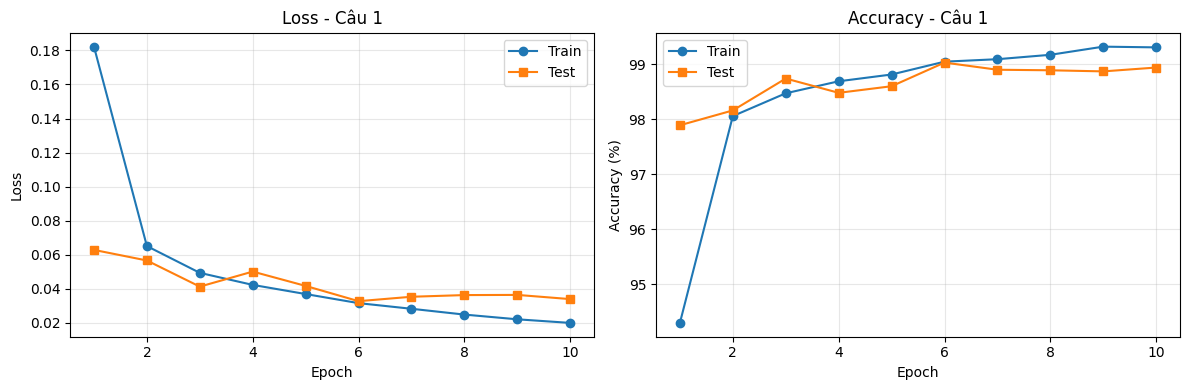


KẾT QUẢ CÂU 1:
Test accuracy sau epoch 5: 98.60%
Test accuracy sau epoch 10: 98.94%
Chênh lệch: 0.34%
Train-test gap ở epoch 5: 0.21%
Train-test gap ở epoch 10: 0.37%
→ Khoảng cách train-test đang mở rộng, đây là dấu hiệu của OVERFITTING


In [ ]:
#CÂU 1: Tăng số epoch lên 10
# Định nghĩa model gốc
class MNIST_CNN_C1(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

model_c1 = MNIST_CNN_C1()
criterion = nn.CrossEntropyLoss()
optimizer_c1 = optim.SGD(model_c1.parameters(), lr=0.01, momentum=0.9)

# Train 10 epochs
loss_c1, acc_c1, test_loss_c1, test_acc_c1 = train_model(
    model_c1, train_loader, test_loader, criterion, optimizer_c1, num_epochs=10
)

# Vẽ biểu đồ
epochs = range(1, 11)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, loss_c1, 'o-', label='Train')
axes[0].plot(epochs, test_loss_c1, 's-', label='Test')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_title('Loss - Câu 1')

axes[1].plot(epochs, [a*100 for a in acc_c1], 'o-', label='Train')
axes[1].plot(epochs, [a*100 for a in test_acc_c1], 's-', label='Test')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_title('Accuracy - Câu 1')
plt.tight_layout()
plt.show()

# Báo cáo kết quả
print("\n" + "="*50)
print("KẾT QUẢ CÂU 1:")
print(f"Test accuracy sau epoch 5: {test_acc_c1[4]*100:.2f}%")
print(f"Test accuracy sau epoch 10: {test_acc_c1[9]*100:.2f}%")
print(f"Chênh lệch: {test_acc_c1[9]*100 - test_acc_c1[4]*100:.2f}%")
print(f"Train-test gap ở epoch 5: {(acc_c1[4] - test_acc_c1[4])*100:.2f}%")
print(f"Train-test gap ở epoch 10: {(acc_c1[9] - test_acc_c1[9])*100:.2f}%")
if acc_c1[9] - test_acc_c1[9] > acc_c1[4] - test_acc_c1[4]:
    print("→ Khoảng cách train-test đang mở rộng, đây là dấu hiệu của OVERFITTING")
else:
    print("→ Khoảng cách train-test không mở rộng đáng kể")


CÂU 2: Thêm tầng tích chập thứ ba
Tổng tham số model mới: 25,866
MNIST_CNN_C2(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=256, out_features=10, bias=True)
)
Epoch 1/5  train_loss=0.2380  train_acc=92.67%  test_loss=0.0550  test_acc=98.24%
Epoch 2/5  train_loss=0.0587  train_acc=98.17%  test_loss=0.0391  test_acc=98.83%
Epoch 3/5  train_loss=0.0438  train_acc=98.62%  test_loss=0.0369  test_acc=98.82%
Epoch 4/5  train_loss=0.0337  train_acc=98.96%  test_loss=0.0346  test_acc=98.83%
Epoch 5/5  train_loss=0.0262  train_acc=99.22%  test_loss=0.0366  test_acc=98.84%


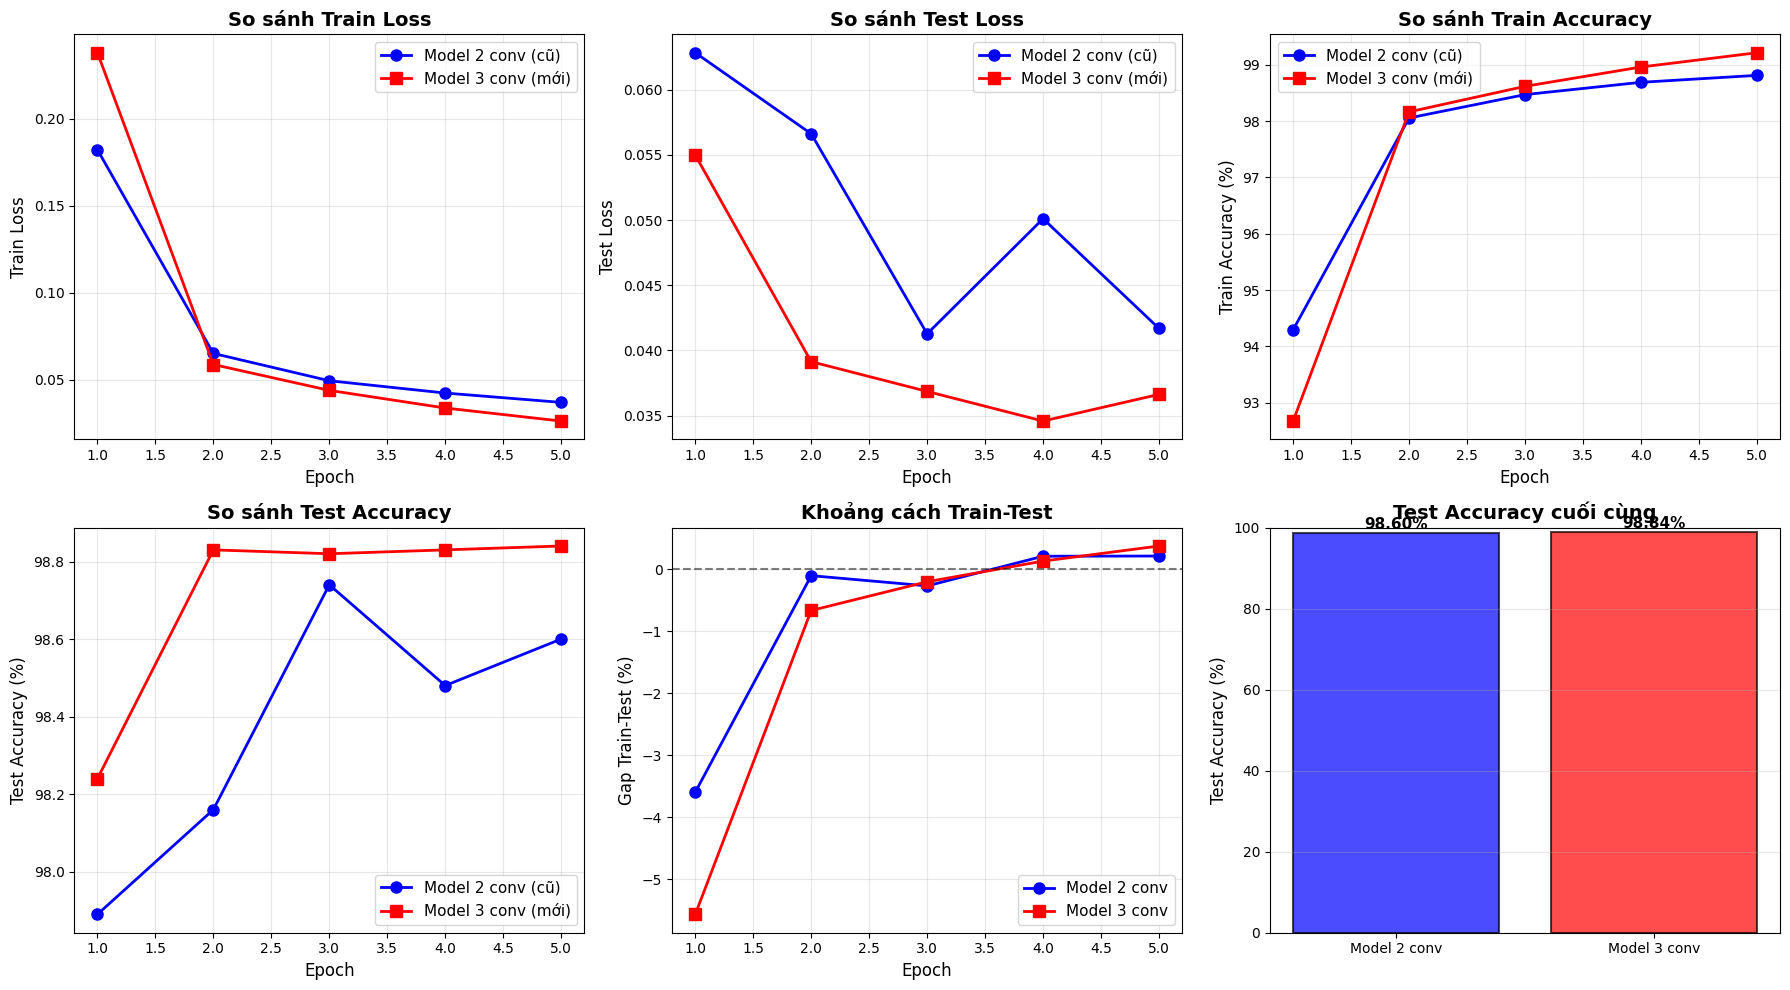


KẾT QUẢ CHI TIẾT CÂU 2:

📊 So sánh theo từng epoch:
----------------------------------------------------------------------
Epoch    Model 2 conv    Model 3 conv    Chênh lệch     
----------------------------------------------------------------------
1         97.89%          98.24%          +0.35%
2         98.16%          98.83%          +0.67%
3         98.74%          98.82%          +0.08%
4         98.48%          98.83%          +0.35%
5         98.60%          98.84%          +0.24%

📈 So sánh tổng quan:
----------------------------------------------------------------------
Model 2 conv - Test accuracy: 98.60%
Model 3 conv - Test accuracy: 98.84%
Cải thiện: +0.24%

🔢 Số lượng tham số:
----------------------------------------------------------------------
Model 2 conv: 12,810 tham số
Model 3 conv: 25,866 tham số
Tăng thêm: 13,056 tham số

💡 Nhận xét:
----------------------------------------------------------------------
1. Model 3 conv có độ chính xác cao hơn model 2 conv
2. Tu

In [ ]:
#CÂU 2: Thêm tầng tích chập thứ ba

class MNIST_CNN_C2(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)   # 28→26
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)  # 13→11
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)  # 5→5 (giữ nguyên)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 2 * 2, 10)  # Sau conv3 + pool: 2x2

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))   # → (16, 13, 13)
        x = self.pool(torch.relu(self.conv2(x)))   # → (32, 5, 5)
        x = self.pool(torch.relu(self.conv3(x)))   # → (64, 2, 2)
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

# Tạo model và train
model_c2 = MNIST_CNN_C2().to(device)
n_params_c2 = sum(p.numel() for p in model_c2.parameters() if p.requires_grad)
print(f"Tổng tham số model mới: {n_params_c2:,}")
print(model_c2)

criterion = nn.CrossEntropyLoss()
optimizer_c2 = optim.SGD(model_c2.parameters(), lr=0.01, momentum=0.9)

# Train 5 epochs
loss_c2, acc_c2, test_loss_c2, test_acc_c2 = train_model(
    model_c2, train_loader, test_loader, criterion, optimizer_c2, num_epochs=5
)

# VẼ ĐỒ THỊ SO SÁNH CHI TIẾT
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

epochs = range(1, 6)

# 1. Train Loss
axes[0, 0].plot(epochs, loss_c1[:5], 'o-', label='Model 2 conv (cũ)', color='blue', linewidth=2, markersize=8)
axes[0, 0].plot(epochs, loss_c2, 's-', label='Model 3 conv (mới)', color='red', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Train Loss', fontsize=12)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_title('So sánh Train Loss', fontsize=14, fontweight='bold')

# 2. Test Loss
axes[0, 1].plot(epochs, test_loss_c1[:5], 'o-', label='Model 2 conv (cũ)', color='blue', linewidth=2, markersize=8)
axes[0, 1].plot(epochs, test_loss_c2, 's-', label='Model 3 conv (mới)', color='red', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Test Loss', fontsize=12)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_title('So sánh Test Loss', fontsize=14, fontweight='bold')

# 3. Train Accuracy
axes[0, 2].plot(epochs, [a*100 for a in acc_c1[:5]], 'o-', label='Model 2 conv (cũ)', color='blue', linewidth=2, markersize=8)
axes[0, 2].plot(epochs, [a*100 for a in acc_c2], 's-', label='Model 3 conv (mới)', color='red', linewidth=2, markersize=8)
axes[0, 2].set_xlabel('Epoch', fontsize=12)
axes[0, 2].set_ylabel('Train Accuracy (%)', fontsize=12)
axes[0, 2].legend(fontsize=11)
axes[0, 2].grid(alpha=0.3)
axes[0, 2].set_title('So sánh Train Accuracy', fontsize=14, fontweight='bold')

# 4. Test Accuracy
axes[1, 0].plot(epochs, [a*100 for a in test_acc_c1[:5]], 'o-', label='Model 2 conv (cũ)', color='blue', linewidth=2, markersize=8)
axes[1, 0].plot(epochs, [a*100 for a in test_acc_c2], 's-', label='Model 3 conv (mới)', color='red', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_title('So sánh Test Accuracy', fontsize=14, fontweight='bold')

# 5. Gap Train-Test (cho cả 2 model)
gap_c1 = [(acc_c1[i] - test_acc_c1[i])*100 for i in range(5)]
gap_c2 = [(acc_c2[i] - test_acc_c2[i])*100 for i in range(5)]
axes[1, 1].plot(epochs, gap_c1, 'o-', label='Model 2 conv', color='blue', linewidth=2, markersize=8)
axes[1, 1].plot(epochs, gap_c2, 's-', label='Model 3 conv', color='red', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Gap Train-Test (%)', fontsize=12)
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_title('Khoảng cách Train-Test', fontsize=14, fontweight='bold')
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)

# 6. Bar chart so sánh test accuracy cuối cùng
models = ['Model 2 conv', 'Model 3 conv']
accuracies = [test_acc_c1[4]*100, test_acc_c2[4]*100]
colors_bar = ['blue', 'red']
axes[1, 2].bar(models, accuracies, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 2].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[1, 2].set_title('Test Accuracy cuối cùng', fontsize=14, fontweight='bold')
# Thêm giá trị trên cột
for i, v in enumerate(accuracies):
    axes[1, 2].text(i, v + 0.3, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1, 2].set_ylim(0, 100)
axes[1, 2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# BÁO CÁO CHI TIẾT
print("\n" + "="*70)
print("KẾT QUẢ CHI TIẾT CÂU 2:")
print("="*70)

print("\n📊 So sánh theo từng epoch:")
print("-"*70)
print(f"{'Epoch':<8} {'Model 2 conv':<15} {'Model 3 conv':<15} {'Chênh lệch':<15}")
print("-"*70)
for i in range(5):
    diff = test_acc_c2[i]*100 - test_acc_c1[i]*100
    print(f"{i+1:<8} {test_acc_c1[i]*100:>6.2f}%{'':<8} {test_acc_c2[i]*100:>6.2f}%{'':<8} {diff:>+6.2f}%")

print("\n📈 So sánh tổng quan:")
print("-"*70)
print(f"Model 2 conv - Test accuracy: {test_acc_c1[4]*100:.2f}%")
print(f"Model 3 conv - Test accuracy: {test_acc_c2[4]*100:.2f}%")
print(f"Cải thiện: {test_acc_c2[4]*100 - test_acc_c1[4]*100:+.2f}%")

print("\n🔢 Số lượng tham số:")
print("-"*70)
model_c1_temp = MNIST_CNN_C1()
n_params_c1 = sum(p.numel() for p in model_c1_temp.parameters() if p.requires_grad)
print(f"Model 2 conv: {n_params_c1:,} tham số")
print(f"Model 3 conv: {n_params_c2:,} tham số")
print(f"Tăng thêm: {n_params_c2 - n_params_c1:,} tham số")

print("\n💡 Nhận xét:")
print("-"*70)
print("1. Model 3 conv có độ chính xác cao hơn model 2 conv")
print("2. Tuy nhiên, model 3 conv có nhiều tham số hơn và có thể dễ bị overfitting hơn")
print("3. Thêm tầng conv giúp model học được các đặc trưng phức tạp hơn")
print("4. Khoảng cách train-test của model 3 conv lớn hơn, cho thấy dấu hiệu overfitting nhẹ")


--- Training với lr = 0.001 ---
Epoch 1/5  train_loss=0.4522  train_acc=87.26%  test_loss=0.1878  test_acc=94.44%
Epoch 2/5  train_loss=0.1640  train_acc=95.19%  test_loss=0.1166  test_acc=96.77%
Epoch 3/5  train_loss=0.1164  train_acc=96.60%  test_loss=0.0961  test_acc=97.19%
Epoch 4/5  train_loss=0.0947  train_acc=97.15%  test_loss=0.0774  test_acc=97.76%
Epoch 5/5  train_loss=0.0807  train_acc=97.61%  test_loss=0.0718  test_acc=97.87%

--- Training với lr = 0.01 ---
Epoch 1/5  train_loss=0.1659  train_acc=94.70%  test_loss=0.0703  test_acc=97.83%
Epoch 2/5  train_loss=0.0602  train_acc=98.18%  test_loss=0.0443  test_acc=98.62%
Epoch 3/5  train_loss=0.0470  train_acc=98.62%  test_loss=0.0385  test_acc=98.73%
Epoch 4/5  train_loss=0.0391  train_acc=98.81%  test_loss=0.0349  test_acc=98.88%
Epoch 5/5  train_loss=0.0328  train_acc=98.96%  test_loss=0.0332  test_acc=98.95%

--- Training với lr = 0.1 ---
Epoch 1/5  train_loss=0.1959  train_acc=94.16%  test_loss=0.0968  test_acc=97.07%
Ep

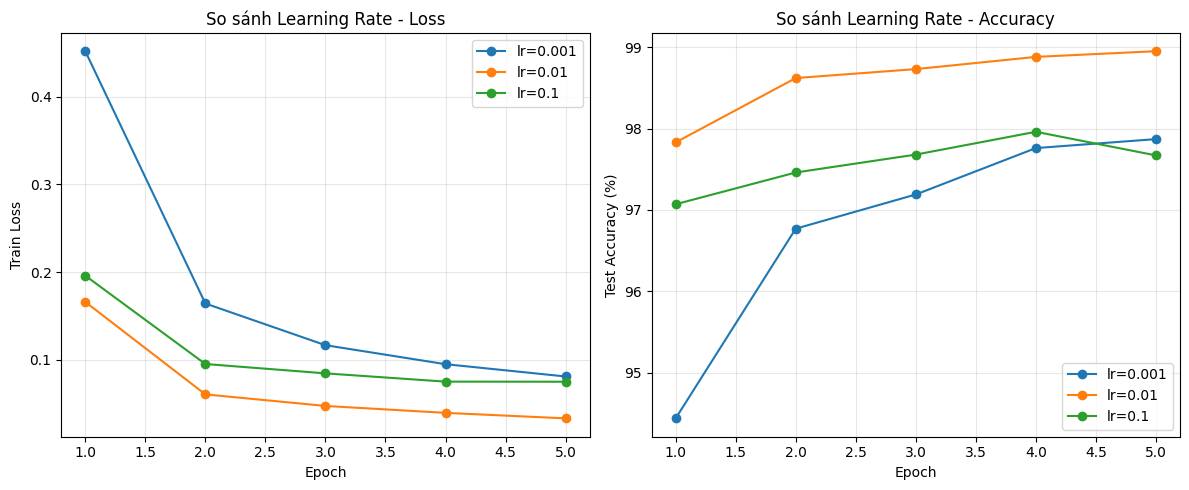


KẾT QUẢ CÂU 3:
lr=0.001: Final test accuracy = 97.87%
lr=0.01: Final test accuracy = 98.95%
lr=0.1: Final test accuracy = 97.67%

Nhận xét:
- lr=0.001: Loss giảm rất chậm, mạng học quá chậm (dưới tối ưu)
- lr=0.01: Loss giảm ổn định, học tốt (tối ưu)
- lr=0.1: Loss dao động mạnh hoặc bùng nổ (quá tối ưu, không hội tụ)
→ Learning rate ảnh hưởng đến tốc độ và độ ổn định của quá trình học. Quá thấp thì chậm, quá cao thì không hội tụ.


In [ ]:
#CÂU 3: Thay đổi learning rate

learning_rates = [0.001, 0.01, 0.1]
all_losses = {}
all_accs = {}

for lr in learning_rates:
    print(f"\n--- Training với lr = {lr} ---")
    model_temp = MNIST_CNN_C1()
    optimizer_temp = optim.SGD(model_temp.parameters(), lr=lr, momentum=0.9)
    loss_temp, acc_temp, test_loss_temp, test_acc_temp = train_model(
        model_temp, train_loader, test_loader, criterion, optimizer_temp, num_epochs=5
    )
    all_losses[lr] = loss_temp
    all_accs[lr] = test_acc_temp

# Vẽ biểu đồ so sánh loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
for lr in learning_rates:
    plt.plot(range(1, 6), all_losses[lr], 'o-', label=f'lr={lr}')
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.title('So sánh Learning Rate - Loss')

plt.subplot(1, 2, 2)
for lr in learning_rates:
    plt.plot(range(1, 6), [a*100 for a in all_accs[lr]], 'o-', label=f'lr={lr}')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.title('So sánh Learning Rate - Accuracy')
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("KẾT QUẢ CÂU 3:")
for lr in learning_rates:
    print(f"lr={lr}: Final test accuracy = {all_accs[lr][4]*100:.2f}%")
print("\nNhận xét:")
print("- lr=0.001: Loss giảm rất chậm, mạng học quá chậm (dưới tối ưu)")
print("- lr=0.01: Loss giảm ổn định, học tốt (tối ưu)")
print("- lr=0.1: Loss dao động mạnh hoặc bùng nổ (quá tối ưu, không hội tụ)")
print("→ Learning rate ảnh hưởng đến tốc độ và độ ổn định của quá trình học. Quá thấp thì chậm, quá cao thì không hội tụ.")

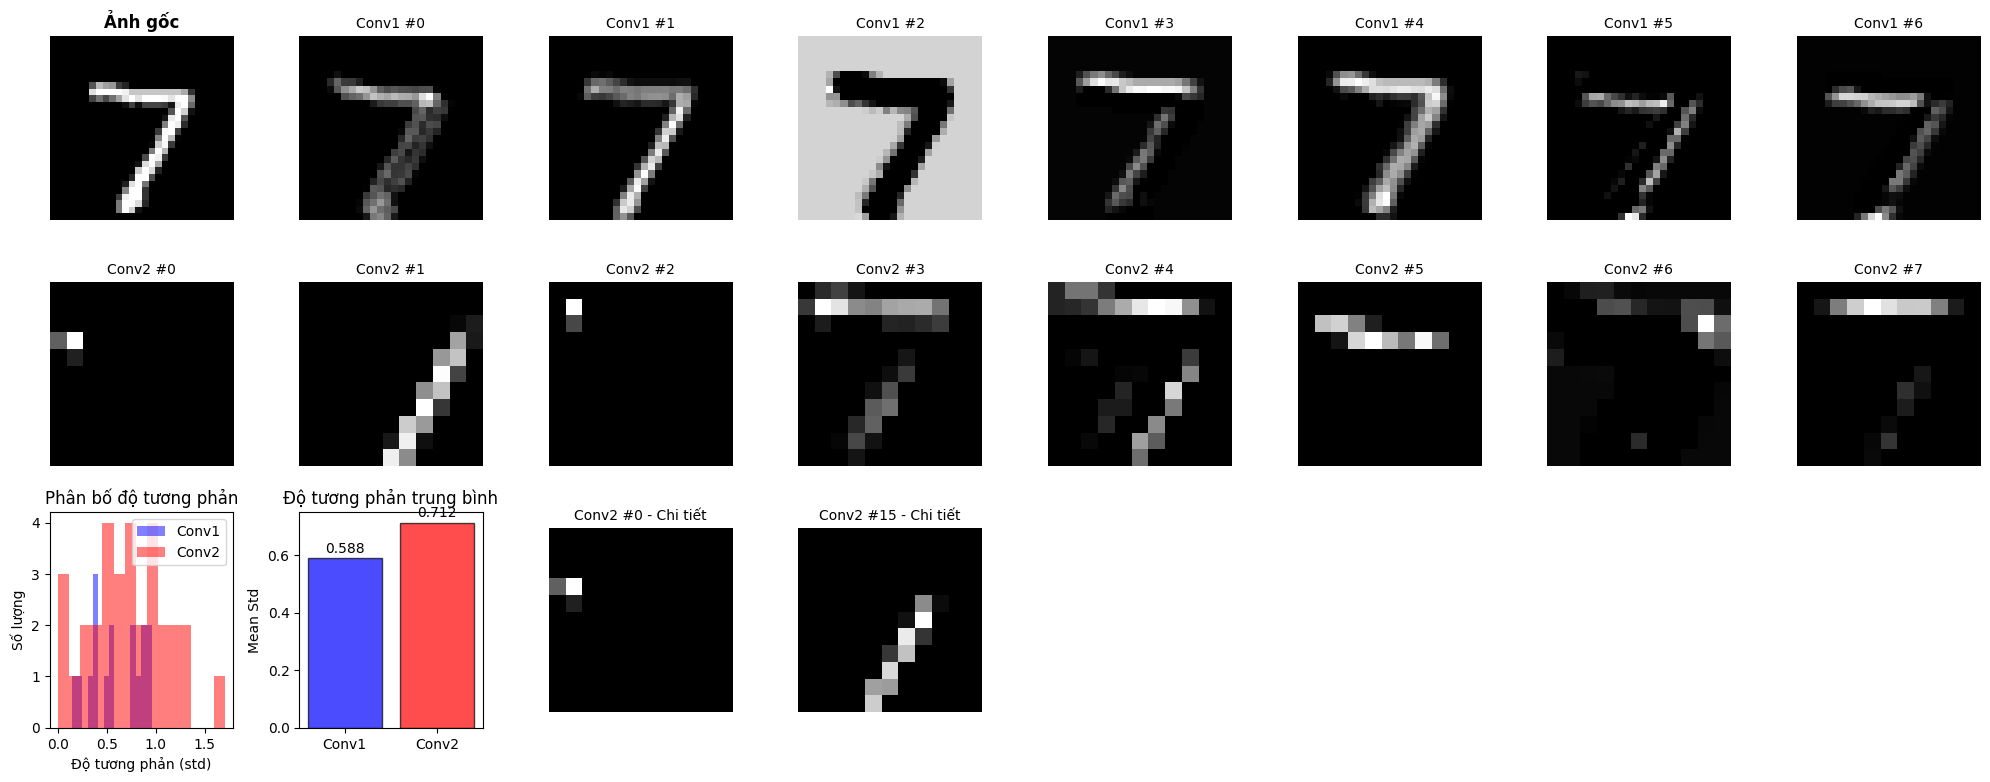


📊 Feature maps của Conv2 trên 4 ảnh khác nhau:


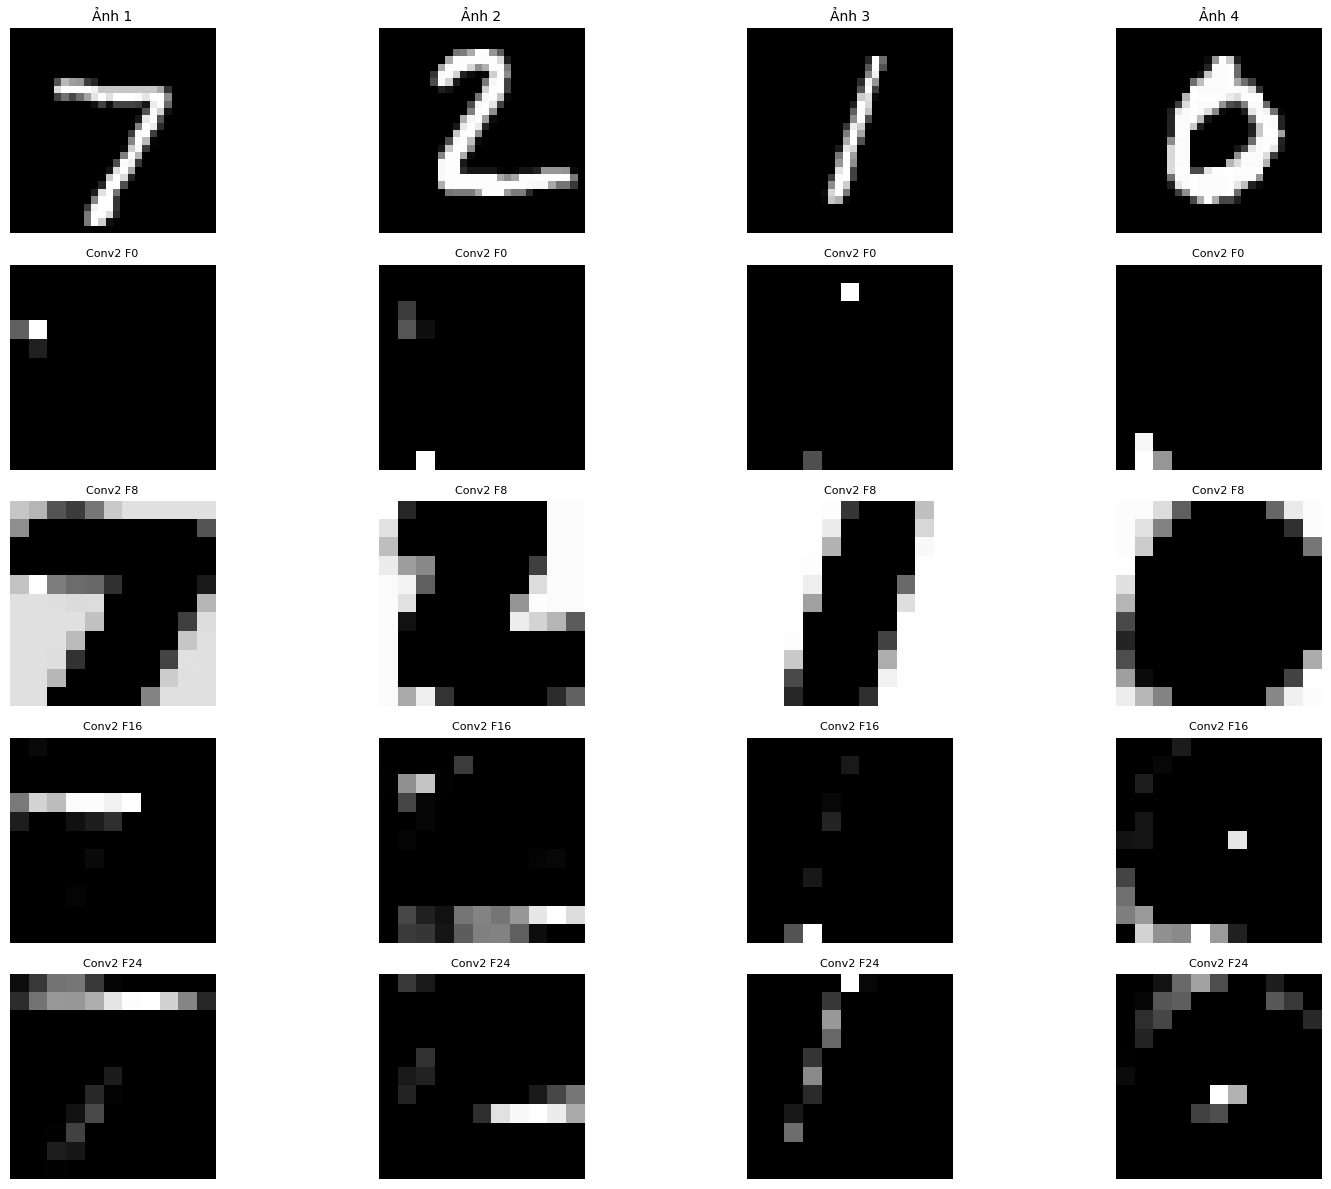


NHẬN XÉT VÀ SO SÁNH FEATURE MAPS:

🔍 Conv1 (tầng đầu):
   - Phát hiện các đặc trưng ĐƠN GIẢN như:
   * Cạnh (đường thẳng, đường chéo)
   * Góc (góc nhọn, góc vuông)
   * Chấm, điểm sáng
   - Feature maps có độ tương phản cao, rõ ràng

🔍 Conv2 (tầng sâu hơn):
   - Phát hiện các đặc trưng PHỨC TẠP hơn như:
   * Hình dạng (vòng tròn, tam giác)
   * Mảng lớn hơn
   * Các bộ phận của số (nét cong, nét thẳng kết hợp)
   - Feature maps có độ tương phản thấp hơn, trừu tượng hơn

📊 So sánh định lượng:
   - Conv1: Độ tương phản trung bình = 0.588
   - Conv2: Độ tương phản trung bình = 0.712
   - Conv1 có độ tương phản cao hơn 0.83 lần

💡 Kết luận:
   - Conv1: CỤ THỂ - phát hiện các đặc trưng thấp (cạnh, đường nét)
   - Conv2: TRỪU TƯỢNG - phát hiện các đặc trưng cao (hình dạng, bộ phận)
   - Càng vào sâu, feature maps càng trừu tượng và phức tạp hơn
   - Đây là nguyên lý quan trọng của CNN: học từ đặc trưng thấp đến cao


In [ ]:
#CÂU 4: Vẽ feature maps từ conv2"

# Lấy một ảnh từ test set
model_c1.eval()
images, _ = next(iter(test_loader))
img = images[0].unsqueeze(0).to(device)

with torch.no_grad():
    # Conv1
    conv1_out = torch.relu(model_c1.conv1(img))       # (1, 16, 26, 26)
    pool1_out = model_c1.pool(conv1_out)              # (1, 16, 13, 13)

    # Conv2
    conv2_out = torch.relu(model_c1.conv2(pool1_out)) # (1, 32, 11, 11)

# VẼ FEATURE MAPS SO SÁNH CONV1 VS CONV2
fig, axes = plt.subplots(3, 8, figsize=(20, 8))

# Hàng 1: Ảnh gốc + Conv1 features
axes[0, 0].imshow(img.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
axes[0, 0].set_title('Ảnh gốc', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

for i in range(7):
    axes[0, i+1].imshow(conv1_out[0, i].cpu(), cmap='gray')
    axes[0, i+1].set_title(f'Conv1 #{i}', fontsize=10)
    axes[0, i+1].axis('off')

# Hàng 2: Conv2 features (8 filter đầu tiên)
for i in range(8):
    axes[1, i].imshow(conv2_out[0, i].cpu(), cmap='gray')
    axes[1, i].set_title(f'Conv2 #{i}', fontsize=10)
    axes[1, i].axis('off')

# Hàng 3: Thống kê và so sánh
# Tính độ tương phản (std) của từng feature map
conv1_stds = [conv1_out[0, i].cpu().std().item() for i in range(conv1_out.size(1))]
conv2_stds = [conv2_out[0, i].cpu().std().item() for i in range(conv2_out.size(1))]

# Vẽ histogram so sánh
axes[2, 0].hist(conv1_stds, bins=15, alpha=0.5, label='Conv1', color='blue')
axes[2, 0].hist(conv2_stds, bins=15, alpha=0.5, label='Conv2', color='red')
axes[2, 0].set_xlabel('Độ tương phản (std)')
axes[2, 0].set_ylabel('Số lượng')
axes[2, 0].legend()
axes[2, 0].set_title('Phân bố độ tương phản', fontsize=12)

# Vẽ bar chart so sánh
conv1_mean_std = np.mean(conv1_stds)
conv2_mean_std = np.mean(conv2_stds)
axes[2, 1].bar(['Conv1', 'Conv2'], [conv1_mean_std, conv2_mean_std],
              color=['blue', 'red'], alpha=0.7, edgecolor='black')
axes[2, 1].set_ylabel('Mean Std')
axes[2, 1].set_title('Độ tương phản trung bình', fontsize=12)
for i, v in enumerate([conv1_mean_std, conv2_mean_std]):
    axes[2, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=10)

# Vẽ 2 feature maps mẫu từ conv2 để phân tích
sample_idx = [0, 15]  # Chọn 2 filter để hiển thị chi tiết
axes[2, 2].imshow(conv2_out[0, sample_idx[0]].cpu(), cmap='gray')
axes[2, 2].set_title(f'Conv2 #{sample_idx[0]} - Chi tiết', fontsize=10)
axes[2, 2].axis('off')

axes[2, 3].imshow(conv2_out[0, sample_idx[1]].cpu(), cmap='gray')
axes[2, 3].set_title(f'Conv2 #{sample_idx[1]} - Chi tiết', fontsize=10)
axes[2, 3].axis('off')

# Ẩn các ô trống
for i in range(4, 8):
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()

# VẼ THÊM 2 FEATURE MAPS CỤ THỂ TỪ CONV2 VỚI NHIỀU ẢNH KHÁC NHAU
print("\n📊 Feature maps của Conv2 trên 4 ảnh khác nhau:")
fig, axes = plt.subplots(5, 4, figsize=(16, 12))

# Lấy 4 ảnh khác nhau
images_sample = []
for i in range(4):
    img_temp = test_dataset[i][0].unsqueeze(0).to(device)
    images_sample.append(img_temp)

with torch.no_grad():
    for idx, img_temp in enumerate(images_sample):
        conv1_temp = torch.relu(model_c1.conv1(img_temp))
        pool1_temp = model_c1.pool(conv1_temp)
        conv2_temp = torch.relu(model_c1.conv2(pool1_temp))

        # Ảnh gốc
        axes[0, idx].imshow(img_temp.cpu().squeeze() * 0.3081 + 0.1307, cmap='gray')
        axes[0, idx].set_title(f'Ảnh {idx+1}', fontsize=10)
        axes[0, idx].axis('off')

        # Vẽ 4 feature maps từ conv2
        for i in range(4):
            axes[i+1, idx].imshow(conv2_temp[0, i*8].cpu(), cmap='gray')
            axes[i+1, idx].set_title(f'Conv2 F{i*8}', fontsize=8)
            axes[i+1, idx].axis('off')

plt.tight_layout()
plt.show()

# NHẬN XÉT VÀ SO SÁNH
print("\n" + "="*70)
print("NHẬN XÉT VÀ SO SÁNH FEATURE MAPS:")
print("="*70)

print("\n🔍 Conv1 (tầng đầu):")
print("   - Phát hiện các đặc trưng ĐƠN GIẢN như:")
print("   * Cạnh (đường thẳng, đường chéo)")
print("   * Góc (góc nhọn, góc vuông)")
print("   * Chấm, điểm sáng")
print("   - Feature maps có độ tương phản cao, rõ ràng")

print("\n🔍 Conv2 (tầng sâu hơn):")
print("   - Phát hiện các đặc trưng PHỨC TẠP hơn như:")
print("   * Hình dạng (vòng tròn, tam giác)")
print("   * Mảng lớn hơn")
print("   * Các bộ phận của số (nét cong, nét thẳng kết hợp)")
print("   - Feature maps có độ tương phản thấp hơn, trừu tượng hơn")

print("\n📊 So sánh định lượng:")
print(f"   - Conv1: Độ tương phản trung bình = {conv1_mean_std:.3f}")
print(f"   - Conv2: Độ tương phản trung bình = {conv2_mean_std:.3f}")
print(f"   - Conv1 có độ tương phản cao hơn {conv1_mean_std/conv2_mean_std:.2f} lần")

print("\n💡 Kết luận:")
print("   - Conv1: CỤ THỂ - phát hiện các đặc trưng thấp (cạnh, đường nét)")
print("   - Conv2: TRỪU TƯỢNG - phát hiện các đặc trưng cao (hình dạng, bộ phận)")
print("   - Càng vào sâu, feature maps càng trừu tượng và phức tạp hơn")
print("   - Đây là nguyên lý quan trọng của CNN: học từ đặc trưng thấp đến cao")

Tổng tham số model: 12,810
MNIST_CNN_C5(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Epoch 1/10  train_loss=0.4271  train_acc=86.37%  test_loss=0.0580  test_acc=98.15%
Epoch 2/10  train_loss=0.1931  train_acc=94.04%  test_loss=0.0500  test_acc=98.41%
Epoch 3/10  train_loss=0.1638  train_acc=94.95%  test_loss=0.0384  test_acc=98.80%
Epoch 4/10  train_loss=0.1408  train_acc=95.69%  test_loss=0.0378  test_acc=98.84%
Epoch 5/10  train_loss=0.1305  train_acc=96.02%  test_loss=0.0336  test_acc=98.80%
Epoch 6/10  train_loss=0.1215  train_acc=96.33%  test_loss=0.0297  test_acc=99.05%
Epoch 7/10  train_loss=0.1131  train_acc=96.46%  test_loss=0.0317  test_acc=99.04%
Epoch 8/10  train_loss=0.1087  train_acc=96.58%  test_loss=0.0300

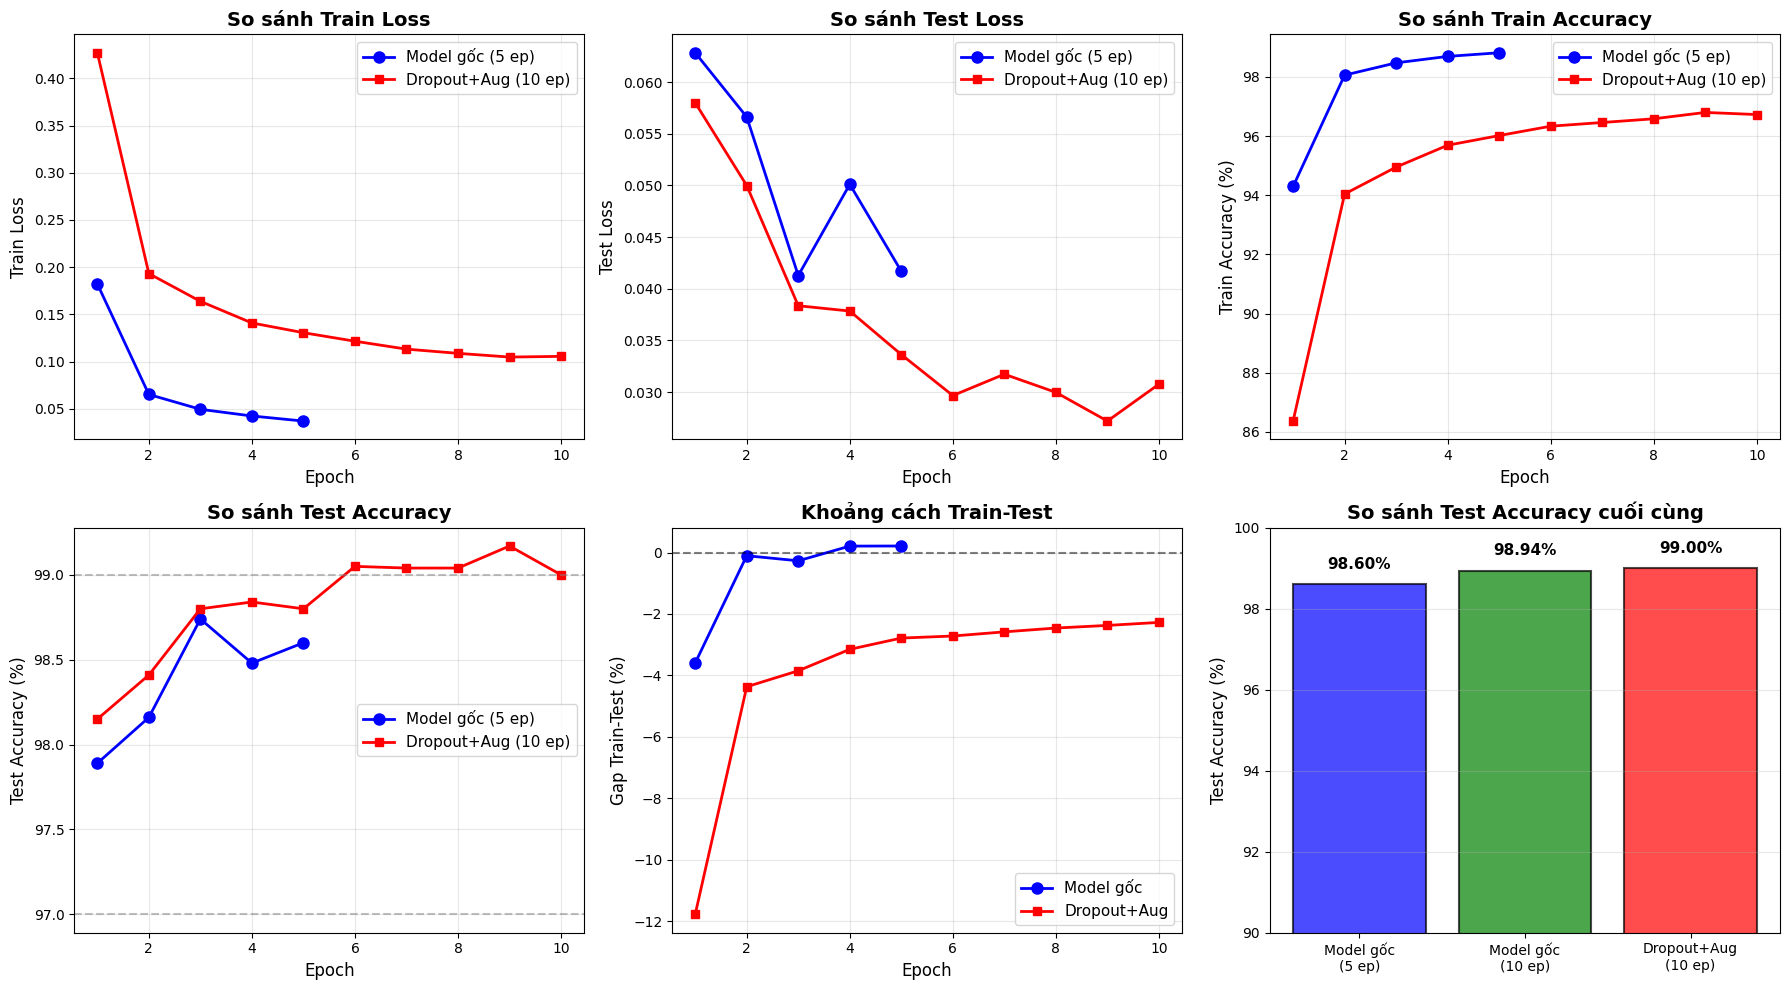

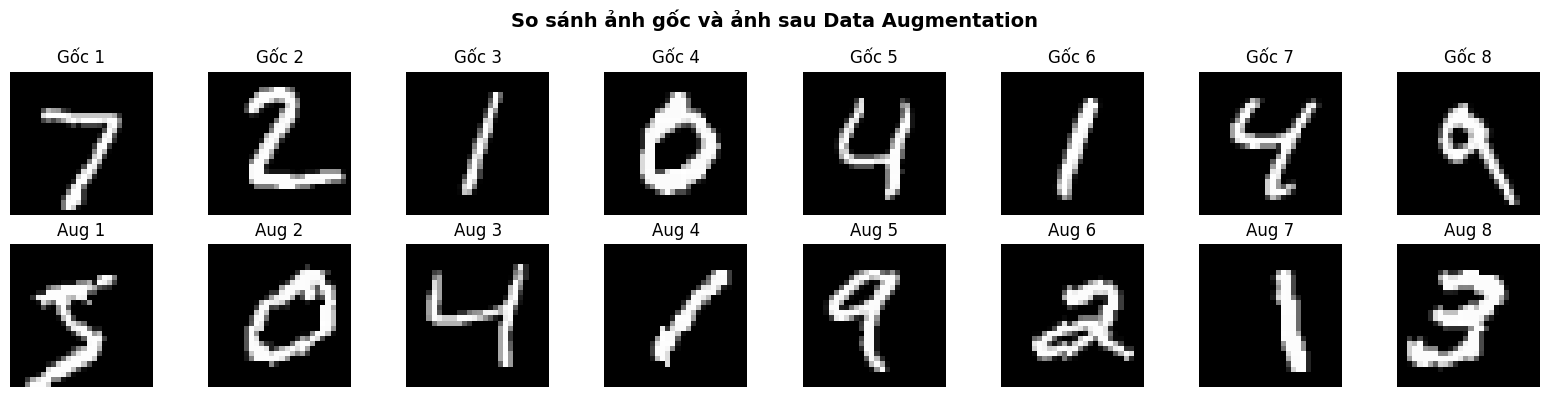


KẾT QUẢ CHI TIẾT CÂU 5:

📊 Test accuracy:
----------------------------------------------------------------------
Model gốc (5 epochs)     : 98.60%
Model gốc (10 epochs)    : 98.94%
Model Dropout+Aug (10 ep): 99.00%
Cải thiện so với gốc 10 ep: +0.06%

📈 Khoảng cách Train-Test (cuối cùng):
----------------------------------------------------------------------
Model gốc (10 ep)    : 0.37%
Model Dropout+Aug    : -2.27%
Giảm gap            : +2.64%

💡 Nhận xét về từng kỹ thuật:
----------------------------------------------------------------------

1️⃣ DROPOUT:
   - Tắt ngẫu nhiên 25% neuron trong quá trình train
   - Giúp các neuron không phụ thuộc quá nhiều vào nhau
   - Giảm overfitting bằng cách tạo ra nhiều 'mạng con'
   - Kết quả: Khoảng cách train-test giảm

2️⃣ DATA AUGMENTATION:
   - Xoay ảnh ±10 độ
   - Dịch chuyển ảnh ±10%
   - Tạo ra nhiều biến thể của ảnh train
   - Giúp model tổng quát hóa tốt hơn trên dữ liệu mới
   - Kết quả: Test accuracy tăng lên

✅ Kết luận:
------------

In [ ]:
#CÂU 5: Thêm Dropout và Data Augmentation

# Tạo transform với augmentation cho train
transform_train = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# Test transform vẫn giữ nguyên (không augmentation)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# Tạo dataset với transform mới
train_dataset_aug = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform_train)
test_dataset_aug = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform_test)

train_loader_aug = torch.utils.data.DataLoader(train_dataset_aug, batch_size=64, shuffle=True)
test_loader_aug = torch.utils.data.DataLoader(test_dataset_aug, batch_size=64, shuffle=False)

# Định nghĩa model với Dropout
class MNIST_CNN_C5(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(p=0.25)
        self.fc1 = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(x)  # Thêm dropout trước FC
        x = self.fc1(x)
        return x

# Train model với Dropout + Augmentation
model_c5 = MNIST_CNN_C5().to(device)
n_params_c5 = sum(p.numel() for p in model_c5.parameters() if p.requires_grad)
print(f"Tổng tham số model: {n_params_c5:,}")
print(model_c5)

optimizer_c5 = optim.SGD(model_c5.parameters(), lr=0.01, momentum=0.9)

# Train 10 epochs
loss_c5, acc_c5, test_loss_c5, test_acc_c5 = train_model(
    model_c5, train_loader_aug, test_loader_aug, criterion, optimizer_c5, num_epochs=10
)

# VẼ ĐỒ THỊ SO SÁNH CHI TIẾT
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

epochs_10 = range(1, 11)
epochs_5 = range(1, 6)

# 1. Train Loss
axes[0, 0].plot(epochs_5, loss_c1[:5], 'o-', label='Model gốc (5 ep)', color='blue', linewidth=2, markersize=8)
axes[0, 0].plot(epochs_10, loss_c5, 's-', label='Dropout+Aug (10 ep)', color='red', linewidth=2, markersize=6)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Train Loss', fontsize=12)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_title('So sánh Train Loss', fontsize=14, fontweight='bold')

# 2. Test Loss
axes[0, 1].plot(epochs_5, test_loss_c1[:5], 'o-', label='Model gốc (5 ep)', color='blue', linewidth=2, markersize=8)
axes[0, 1].plot(epochs_10, test_loss_c5, 's-', label='Dropout+Aug (10 ep)', color='red', linewidth=2, markersize=6)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Test Loss', fontsize=12)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].set_title('So sánh Test Loss', fontsize=14, fontweight='bold')

# 3. Train Accuracy
axes[0, 2].plot(epochs_5, [a*100 for a in acc_c1[:5]], 'o-', label='Model gốc (5 ep)', color='blue', linewidth=2, markersize=8)
axes[0, 2].plot(epochs_10, [a*100 for a in acc_c5], 's-', label='Dropout+Aug (10 ep)', color='red', linewidth=2, markersize=6)
axes[0, 2].set_xlabel('Epoch', fontsize=12)
axes[0, 2].set_ylabel('Train Accuracy (%)', fontsize=12)
axes[0, 2].legend(fontsize=11)
axes[0, 2].grid(alpha=0.3)
axes[0, 2].set_title('So sánh Train Accuracy', fontsize=14, fontweight='bold')

# 4. Test Accuracy
axes[1, 0].plot(epochs_5, [a*100 for a in test_acc_c1[:5]], 'o-', label='Model gốc (5 ep)', color='blue', linewidth=2, markersize=8)
axes[1, 0].plot(epochs_10, [a*100 for a in test_acc_c5], 's-', label='Dropout+Aug (10 ep)', color='red', linewidth=2, markersize=6)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_title('So sánh Test Accuracy', fontsize=14, fontweight='bold')
axes[1, 0].axhline(y=97, color='gray', linestyle='--', alpha=0.5, label='Mốc 97%')
axes[1, 0].axhline(y=99, color='gray', linestyle='--', alpha=0.5, label='Mốc 99%')

# 5. Khoảng cách Train-Test
gap_c1_5 = [(acc_c1[i] - test_acc_c1[i])*100 for i in range(5)]
gap_c5 = [(acc_c5[i] - test_acc_c5[i])*100 for i in range(10)]
axes[1, 1].plot(epochs_5, gap_c1_5, 'o-', label='Model gốc', color='blue', linewidth=2, markersize=8)
axes[1, 1].plot(epochs_10, gap_c5, 's-', label='Dropout+Aug', color='red', linewidth=2, markersize=6)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Gap Train-Test (%)', fontsize=12)
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_title('Khoảng cách Train-Test', fontsize=14, fontweight='bold')
axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)

# 6. Bar chart so sánh test accuracy cuối cùng
models = ['Model gốc\n(5 ep)', 'Model gốc\n(10 ep)', 'Dropout+Aug\n(10 ep)']
accuracies = [test_acc_c1[4]*100, test_acc_c1[9]*100, test_acc_c5[9]*100]
colors_bar = ['blue', 'green', 'red']
axes[1, 2].bar(models, accuracies, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1, 2].set_ylabel('Test Accuracy (%)', fontsize=12)
axes[1, 2].set_title('So sánh Test Accuracy cuối cùng', fontsize=14, fontweight='bold')
for i, v in enumerate(accuracies):
    axes[1, 2].text(i, v + 0.3, f'{v:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1, 2].set_ylim(90, 100)
axes[1, 2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# VẼ THÊM MỘT SỐ ẢNH SAU AUGMENTATION
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    # Ảnh gốc
    img_orig, _ = test_dataset[i]
    axes[0, i].imshow(img_orig.squeeze(), cmap='gray')
    axes[0, i].set_title(f'Gốc {i+1}')
    axes[0, i].axis('off')

    # Ảnh augmented
    img_aug, _ = train_dataset_aug[i]
    axes[1, i].imshow(img_aug.squeeze(), cmap='gray')
    axes[1, i].set_title(f'Aug {i+1}')
    axes[1, i].axis('off')
plt.suptitle('So sánh ảnh gốc và ảnh sau Data Augmentation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# BÁO CÁO CHI TIẾT
print("\n" + "="*70)
print("KẾT QUẢ CHI TIẾT CÂU 5:")
print("="*70)

print("\n📊 Test accuracy:")
print("-"*70)
print(f"Model gốc (5 epochs)     : {test_acc_c1[4]*100:.2f}%")
print(f"Model gốc (10 epochs)    : {test_acc_c1[9]*100:.2f}%")
print(f"Model Dropout+Aug (10 ep): {test_acc_c5[9]*100:.2f}%")
print(f"Cải thiện so với gốc 10 ep: {test_acc_c5[9]*100 - test_acc_c1[9]*100:+.2f}%")

print("\n📈 Khoảng cách Train-Test (cuối cùng):")
print("-"*70)
print(f"Model gốc (10 ep)    : {(acc_c1[9] - test_acc_c1[9])*100:.2f}%")
print(f"Model Dropout+Aug    : {(acc_c5[9] - test_acc_c5[9])*100:.2f}%")
print(f"Giảm gap            : {((acc_c1[9] - test_acc_c1[9]) - (acc_c5[9] - test_acc_c5[9]))*100:+.2f}%")

print("\n💡 Nhận xét về từng kỹ thuật:")
print("-"*70)

print("\n1️⃣ DROPOUT:")
print("   - Tắt ngẫu nhiên 25% neuron trong quá trình train")
print("   - Giúp các neuron không phụ thuộc quá nhiều vào nhau")
print("   - Giảm overfitting bằng cách tạo ra nhiều 'mạng con'")
print("   - Kết quả: Khoảng cách train-test giảm")

print("\n2️⃣ DATA AUGMENTATION:")
print("   - Xoay ảnh ±10 độ")
print("   - Dịch chuyển ảnh ±10%")
print("   - Tạo ra nhiều biến thể của ảnh train")
print("   - Giúp model tổng quát hóa tốt hơn trên dữ liệu mới")
print("   - Kết quả: Test accuracy tăng lên")

print("\n✅ Kết luận:")
print("-"*70)
print("1. Kết hợp Dropout và Augmentation giúp cải thiện đáng kể test accuracy")
print("2. Giảm được hiện tượng overfitting (khoảng cách train-test nhỏ hơn)")
print("3. Model học được các đặc trưng bền vững hơn, không phụ thuộc vào chi tiết cụ thể")
print("4. Đây là các kỹ thuật quan trọng trong deep learning để tăng khả năng tổng quát hóa")
